In [1]:
import pandas as pd 

df  = pd.read_csv("data/data.csv")


In [2]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.shape

(4600, 18)

In [4]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

## Check for missing values

In [5]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

## Check the data types

In [6]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [7]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]

target = "price"

In [8]:
X = df[features]
y = df[target]

In [9]:
X.shape

(4600, 12)

In [10]:
y.shape

(4600,)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create scaler
scaler = StandardScaler()

# Learn mean and standard deviation from training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled

array([[ 0.67051991,  0.43690203,  0.66097147, ..., -0.67958227,
         0.62672137, -0.82244584],
       [ 0.67051991,  1.07491769,  1.65201056, ..., -0.67958227,
         0.6939252 , -0.82244584],
       [ 0.67051991,  0.43690203,  0.70269944, ..., -0.67958227,
         0.39150796, -0.82244584],
       ...,
       [-0.43006585, -1.47714495, -1.02901096, ..., -0.33515114,
        -1.28858778,  1.17817606],
       [-1.5306516 , -1.47714495, -1.27937873, ..., -0.67958227,
        -2.36384905,  1.22619916],
       [-1.5306516 , -1.47714495, -0.67432329, ...,  0.6766153 ,
        -1.38939352, -0.82244584]], shape=(3680, 12))

In [13]:
import numpy as np

w_init = np.zeros(X_train_scaled.shape[1])
b_init = 0

In [14]:
w_init

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
def compute_cost(X, y, w, b):

    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        f_wb = np.dot(X[i],w) + b
        cost = cost + (f_wb - y[i])**2

    cost = cost / (2 * m)
    return cost


In [19]:
cost = compute_cost(X_train_scaled, y_train.values, w_init, b_init)

In [23]:
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 219472765562.59448


In [25]:
def compute_gradient(X, y, w, b):

    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        f_wb = np.dot(X[i],w) + b
        err = f_wb - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [71]:
tmp_dj_dw, tmp_dj_db = compute_gradient(X_train_scaled, y_train.values, w_init, b_init)

In [72]:
print(f'dj_db at initial w,b: {tmp_dj_db}')

dj_db at initial w,b: -544848.268832546


In [73]:
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_dw at initial w,b: 
 [-118248.01021106 -189724.15673618 -256157.88513574  -28941.47348355
  -96066.61608452  -83999.73134785 -135326.32022139  -15930.09875836
 -217486.48136653 -126451.65010453  -12044.73881513   12376.7853056 ]


In [77]:
import math
import copy

def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(X, y, w, b)   ##None

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               ##None
        b = b - alpha * dj_db               ##None
      
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")
        
    return w, b, J_history #return final w,b and J history for graphing

In [ ]:
# some gradient descent settings
iterations = 1000
alpha = 1e-4 # 5e-7 -> 1e-5 -> 1e-4

In [83]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 219421597469.56
Iteration  100: Cost 214406674242.61
Iteration  200: Cost 209586034143.23
Iteration  300: Cost 204949078279.56
Iteration  400: Cost 200485900712.96
Iteration  500: Cost 196187239976.01
Iteration  600: Cost 192044434060.30
Iteration  700: Cost 188049378623.62
Iteration  800: Cost 184194488184.50
Iteration  900: Cost 180472660088.73


In [84]:
alpha = 5e-4

In [85]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 219217027906.97
Iteration  100: Cost 196010733979.50
Iteration  200: Cost 176723906918.65
Iteration  300: Cost 160456974581.84
Iteration  400: Cost 146558824191.79
Iteration  500: Cost 134552510257.21
Iteration  600: Cost 124083842113.94
Iteration  700: Cost 114885727895.35
Iteration  800: Cost 106753378860.86
Iteration  900: Cost 99527007541.24


In [86]:
alpha = 1e-3

In [87]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 218961547275.25
Iteration  100: Cost 176532425142.01
Iteration  200: Cost 146411188927.10
Iteration  300: Cost 123966937185.98
Iteration  400: Cost 106658775850.01
Iteration  500: Cost 93001909670.76
Iteration  600: Cost 82065605729.49
Iteration  700: Cost 73225024976.82
Iteration  800: Cost 66035198411.52
Iteration  900: Cost 60164505949.01


In [88]:
alpha = 5e-3

In [89]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 216926955081.83
Iteration  100: Cost 92382276701.96
Iteration  200: Cost 55098799841.16
Iteration  300: Cost 41384791134.84
Iteration  400: Cost 36135095052.12
Iteration  500: Cost 34054950533.10
Iteration  600: Cost 33190800231.69
Iteration  700: Cost 32807993629.97
Iteration  800: Cost 32624531618.30
Iteration  900: Cost 32528917049.11


In [90]:
iterations = 5000

In [91]:
w_final, b_final, J_hist = gradient_descent(X_train_scaled, y_train.values, w_init, b_init,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)

Iteration    0: Cost 216926955081.83
Iteration  500: Cost 34054950533.10
Iteration 1000: Cost 32475101038.90
Iteration 1500: Cost 32395336890.23
Iteration 2000: Cost 32384769533.10
Iteration 2500: Cost 32382948325.99
Iteration 3000: Cost 32382558365.75
Iteration 3500: Cost 32382457917.61
Iteration 4000: Cost 32382428791.29
Iteration 4500: Cost 32382419809.54


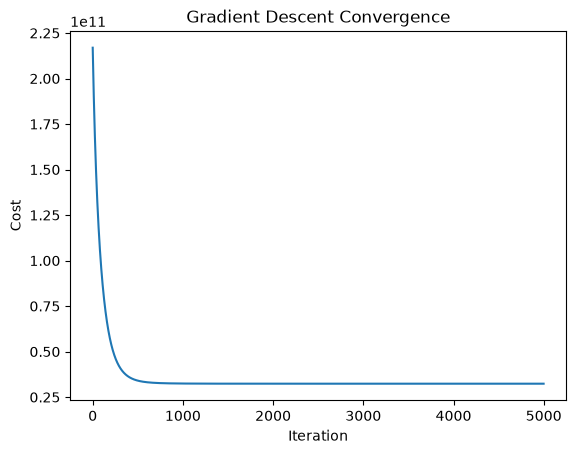

In [92]:
import matplotlib.pyplot as plt

plt.plot(J_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

In [94]:
y_pred = np.dot(X_test_scaled, w_final) + b_final

In [96]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,5.440000e+05,3.048835e+05
1,0.000000e+00,3.265132e+05
2,1.712500e+06,1.071757e+06
3,3.650000e+05,5.462563e+05
4,2.750000e+05,3.798570e+05
5,6.250000e+05,6.057522e+05
6,4.530000e+05,4.812099e+05
7,3.000000e+05,4.189053e+05
8,4.179857e+05,5.093287e+05
9,6.725000e+05,5.308432e+05


In [97]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

210905.92198305883
